# Notebook 05: Comprehensive Evaluation

## Purpose

Notebooks 03 and 04 each evaluated their own model in isolation. This notebook evaluates the **complete two-stage pipeline** (FAISS retrieval + XGBoost ranking) as a unified system, answering questions that no single notebook can:

- How does the pipeline perform across different types of users (heavy raters vs. casual, niche vs. mainstream)?
- Which movie genres does the system rank well, and which does it struggle with?
- Is the system fast enough for production (sub-100ms)?
- Does the model over-recommend popular movies at the expense of catalog diversity?
- Are the model's confidence scores well-calibrated to actual relevance?

## What we consume

| Input | Source | Purpose |
|-------|--------|---------|
| `models/xgboost_ranker.json` | Notebook 04 | Trained ranking model |
| `models/faiss_index_128dim.bin` | Notebook 03 | Candidate retrieval index |
| `models/user_embeddings_128dim.npy` | Notebook 03 | User embeddings for FAISS |
| `models/item_embeddings_128dim.npy` | Notebook 03 | Item embeddings |
| `data/processed/test_set.parquet` | Notebook 02 | Held-out test interactions |
| `data/processed/test_interaction_features.parquet` | Notebook 02 | Test cross-features |
| `data/processed/user_features.parquet` | Notebook 02 | User profiles |
| `data/processed/item_features.parquet` | Notebook 02 | Item profiles |
| `data/processed/metadata.pkl` | Notebook 02 | ID mappings |
| `data/ml-25m/movies.csv` | Raw data | Movie titles and genres |

## Evaluation philosophy

We evaluate on the **test set** throughout -- data the model never saw during training or validation. This gives an unbiased estimate of production performance.

All metrics are computed **per user** and then aggregated. This prevents high-activity users (who have more test interactions) from dominating the averages.

## Setup and Data Loading

We load all model artifacts and the test set. The test set contains 228K interactions from ~4,000 users spanning a time period after the training and validation windows.

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import os
import gc
from pathlib import Path
from collections import defaultdict

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import xgboost as xgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import faiss

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')

# Load metadata
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

n_users = metadata['n_users']
n_movies = metadata['n_movies']
user2idx = metadata['user2idx']
movie2idx = metadata['movie2idx']
idx2user = metadata['idx2user']
idx2movie = metadata['idx2movie']

# Load embeddings
user_embeddings = np.load(MODEL_DIR / 'user_embeddings_128dim.npy')
item_embeddings = np.load(MODEL_DIR / 'item_embeddings_128dim.npy')

# Load feature matrices
user_features_df = pd.read_parquet(DATA_DIR / 'user_features.parquet')
item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')
user_feat_cols = user_features_df.columns.tolist()
item_feat_cols = item_features_df.columns.tolist()

user_feat_matrix = np.zeros((n_users, len(user_feat_cols)), dtype=np.float32)
for uid, uidx in user2idx.items():
    if uid in user_features_df.index:
        user_feat_matrix[uidx] = user_features_df.loc[uid].values

item_feat_matrix = np.zeros((n_movies, len(item_feat_cols)), dtype=np.float32)
for mid, midx in movie2idx.items():
    if mid in item_features_df.index:
        item_feat_matrix[midx] = item_features_df.loc[mid].values

# Load models
index = faiss.read_index(str(MODEL_DIR / 'faiss_index_128dim.bin'))
ranker = xgb.Booster()
ranker.load_model(str(MODEL_DIR / 'xgboost_ranker.json'))

with open(MODEL_DIR / 'ranker_feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

# Load test set
test_df = pd.read_parquet(DATA_DIR / 'test_set.parquet')
test_interaction_feats = pd.read_parquet(DATA_DIR / 'test_interaction_features.parquet')
valid_mask = test_df['user_idx'] > 0
test_df = test_df[valid_mask].reset_index(drop=True)
test_interaction_feats = test_interaction_feats[valid_mask].reset_index(drop=True)

# Load movie metadata
movies_df = pd.read_csv('../data/ml-25m/movies.csv')
movie_titles = dict(zip(movies_df['movieId'], movies_df['title']))
movie_genres_str = dict(zip(movies_df['movieId'], movies_df['genres']))

print(f'Test set: {len(test_df):,} interactions, {test_df["user_idx"].nunique():,} users')
print(f'Models loaded: FAISS ({index.ntotal:,} items, dim={index.d}), XGBoost ({ranker.num_boosted_rounds()} trees)')
print(f'Features: {len(feature_names)} per (user, item) pair')

Test set: 228,448 interactions, 4,005 users
Models loaded: FAISS (21,082 items, dim=128), XGBoost (205 trees)
Features: 105 per (user, item) pair


## End-to-End Pipeline Function

Before computing metrics, we define the complete inference pipeline that mirrors production: FAISS retrieval followed by XGBoost re-ranking. This function is called once per user and returns the ranked candidate list with scores.

In [2]:
def full_pipeline_for_user(user_idx, n_candidates=200, top_k=None):
    """
    Run the full two-stage pipeline for a single user.
    Returns: (candidate_movie_idxs, ranker_scores, retrieval_scores, timings)
    """
    timings = {}

    # Stage 1: FAISS retrieval
    t0 = time.perf_counter()
    user_emb = user_embeddings[user_idx:user_idx+1]
    scores, positions = index.search(user_emb, n_candidates)
    timings['retrieval_ms'] = (time.perf_counter() - t0) * 1000

    candidate_idxs = positions[0]
    retrieval_scores = scores[0]

    # Stage 2: Build features
    t0 = time.perf_counter()
    n_cands = len(candidate_idxs)
    n_features = 1 + len(user_feat_cols) + len(item_feat_cols) + 7
    X_cand = np.zeros((n_cands, n_features), dtype=np.float32)

    X_cand[:, 0] = retrieval_scores
    X_cand[:, 1:1+len(user_feat_cols)] = user_feat_matrix[user_idx]
    X_cand[:, 1+len(user_feat_cols):1+len(user_feat_cols)+len(item_feat_cols)] = item_feat_matrix[candidate_idxs]

    # Cross-features
    user_genre_prefs = user_feat_matrix[user_idx, 4:23]
    X_cand[:, -7] = item_feat_matrix[candidate_idxs, :19] @ user_genre_prefs
    X_cand[:, -6] = item_feat_matrix[candidate_idxs, 20] - user_feat_matrix[user_idx, 23]
    timings['feature_ms'] = (time.perf_counter() - t0) * 1000

    # Stage 3: XGBoost prediction
    t0 = time.perf_counter()
    dcand = xgb.DMatrix(X_cand, feature_names=feature_names)
    ranker_scores = ranker.predict(dcand)
    timings['ranking_ms'] = (time.perf_counter() - t0) * 1000

    timings['total_ms'] = timings['retrieval_ms'] + timings['feature_ms'] + timings['ranking_ms']

    if top_k:
        top_indices = np.argsort(ranker_scores)[::-1][:top_k]
        return candidate_idxs[top_indices], ranker_scores[top_indices], retrieval_scores[top_indices], timings

    return candidate_idxs, ranker_scores, retrieval_scores, timings


# Build test ground truth: for each user, which movies did they actually like?
test_positives = test_df[test_df['label'] == 1].groupby('user_idx')['movie_idx'].apply(set).to_dict()
test_all = test_df.groupby('user_idx')['movie_idx'].apply(set).to_dict()
test_users = sorted(test_positives.keys())

print(f'Test users with positives: {len(test_users):,}')
print(f'Avg positives per user: {np.mean([len(v) for v in test_positives.values()]):.1f}')
print(f'Avg total test interactions per user: {np.mean([len(v) for v in test_all.values()]):.1f}')

Test users with positives: 3,928
Avg positives per user: 33.8
Avg total test interactions per user: 57.0


### Reasoning: Ground Truth Construction Methodology

**What we build:** `test_positives[user_idx] = set(movie_idxs)` using only label=1 interactions (original ratings >= 3.5, converted to implicit positive signal).

**What we deliberately EXCLUDE:** label=0 interactions (ratings < 3.5 -- movies the user watched but rated poorly, i.e., 0.5 to 3.0 stars).

**Why this distinction matters:**

The recommendation task is "suggest movies the user will ENJOY," not "suggest movies the user will WATCH." A movie rated 2.0 was watched (the user chose to invest 2 hours) but was disappointing. Recommending similar movies would hurt user satisfaction -- it would repeat their mistakes rather than learn from them.

**Worked example:** User #100 has 57 test interactions total: 33.8 positive on average (rated 3.5-5.0, movies they genuinely liked) and 23.2 negative (rated 0.5-3.0, movies they watched but found mediocre or bad). We evaluate ONLY against the ~34 positives. If our top-10 pipeline output contains 3 of these 34 positives, that is Precision@10 = 0.30 for that user.

**Our specific numbers:**
- Total test users with positives: 3,928
- Average positives per test user: 33.8
- Average total test interactions per user: 57.0
- This means on average ~23 of each user's test interactions are negative (watched but disliked)

**How this connects to the pipeline ceiling:**

Average positives per test user = 33.8. Recall@200 from Notebook 03 was 0.268 on validation. Applying this to test: approximately 33.8 x 0.23 = ~7.8 relevant items land in our 200-candidate FAISS pool. The XGBoost ranker then tries to promote these ~8 items into the top-10 display positions out of 200 total candidates.

**Why this evaluation is CONSERVATIVE:**

In reality, users might enjoy many movies they have not rated yet. Our ground truth only includes movies they (a) actually watched AND (b) rated >= 3.5 during the specific test time period. Consider:
- A user would love "Arrival" (2016) but never got around to watching it -- this appears as neither positive nor negative; it is simply absent from ground truth
- Our system recommends "Arrival" to this user -- this counts as a FALSE POSITIVE in our metrics (no credit given)
- In production, this would be an excellent recommendation that delights the user

This is the standard offline evaluation limitation: we can only measure against observed behavior, not true latent preferences. **Our metrics underestimate actual model quality** because many "false positives" are genuinely good recommendations for movies the user has not yet discovered. This is particularly relevant for our long-tail analysis: recommending an obscure but excellent film that the user hasn't seen appears as a miss in our metrics even though it represents the ideal recommendation.

## Section 1: Ranking Quality Metrics

### Why ranking quality matters

A recommendation system's job is to put the best items at the top of the list. A user browsing a movie homepage will see positions 1-10 prominently, might scroll to positions 11-20, and rarely looks beyond position 20. Therefore, a mistake at position 1 (showing an irrelevant movie first) is far more costly than a mistake at position 50.

Ranking metrics quantify this: they measure how good the ordering is, with heavier weight on top positions.

### Metrics we compute

**NDCG@K (Normalized Discounted Cumulative Gain)**

Imagine a user's true top-10 would be: [good, good, good, bad, good, bad, bad, bad, bad, bad]. NDCG asks: "How close is our ranked list to this ideal ordering?"

- NDCG@10 = 1.0: Perfect -- every relevant movie is ranked above every irrelevant one in the top 10
- NDCG@10 = 0.8: Good -- most relevant movies are near the top, maybe one slipped to position 5-8
- NDCG@10 = 0.5: Mediocre -- relevant movies are scattered randomly within the top 10
- NDCG@10 = 0.3: Poor -- relevant movies tend to appear at the bottom of the list

The "discounted" part means position 1 matters most (log2 weighting). Getting position 1 right is worth more than getting position 10 right.

**Precision@K**

Simple fraction: of the top K items shown, how many are relevant?

- Precision@10 = 0.7: 7 out of 10 shown movies are ones the user would enjoy
- Precision@10 = 0.3: only 3 out of 10 are relevant -- 7 wasted slots
- Precision@10 = 0.0: none of the top 10 are relevant (terrible)

**MRR (Mean Reciprocal Rank)**

"How far does the user need to scroll before finding something they like?"

- MRR = 1.0: the first recommended movie is always relevant (perfect)
- MRR = 0.5: on average, the first relevant movie is at position 2
- MRR = 0.33: on average, the first relevant movie is at position 3
- MRR = 0.1: the first relevant movie is around position 10 (user gives up scrolling)

**MAP (Mean Average Precision)**

Unlike Precision@K which only looks at one cutoff, MAP averages precision at every position where a relevant item appears. It rewards systems that cluster relevant items at the top rather than spreading them out.

- MAP = 0.8: relevant movies are concentrated at the very top of the list
- MAP = 0.4: relevant movies are mixed throughout the list
- MAP = 0.1: relevant movies are mostly buried deep

**AUC (Area Under ROC Curve)**

"If I pick one movie the user liked and one they didn't, how often does the model score the liked one higher?"

- AUC = 1.0: always ranks liked movies above disliked (perfect)
- AUC = 0.5: random coin flip (useless model)
- AUC = 0.7: correct 70% of the time (decent)

### What "good" looks like for movie recommendation

| Metric | Poor | Acceptable | Good | Excellent |
|--------|------|-----------|------|-----------|
| NDCG@10 | <0.5 | 0.5-0.7 | 0.7-0.85 | >0.85 |
| Precision@10 | <0.3 | 0.3-0.5 | 0.5-0.7 | >0.7 |
| MRR | <0.3 | 0.3-0.6 | 0.6-0.8 | >0.8 |
| MAP | <0.2 | 0.2-0.4 | 0.4-0.6 | >0.6 |
| AUC | <0.6 | 0.6-0.7 | 0.7-0.8 | >0.8 |

In [3]:
# Compute ranking metrics on the test set using the full pipeline
# For each test user, we run FAISS + XGBoost and evaluate against their actual test positives

def compute_all_ranking_metrics(test_users, test_positives, test_all, max_users=3000, n_candidates=200):
    """Compute comprehensive ranking metrics for the full pipeline."""
    K_values = [5, 10, 20]
    metrics = {f'ndcg@{k}': [] for k in K_values}
    metrics.update({f'precision@{k}': [] for k in K_values})
    metrics['mrr'] = []
    metrics['map'] = []
    metrics['auc'] = []

    users_evaluated = 0
    for user_idx in test_users[:max_users]:
        positives = test_positives.get(user_idx, set())
        if len(positives) < 2:
            continue

        # Run full pipeline
        candidate_idxs, ranker_scores, _, _ = full_pipeline_for_user(user_idx, n_candidates)

        # Build labels for candidates: 1 if in test positives, 0 otherwise
        candidate_labels = np.array([1.0 if idx in positives else 0.0 for idx in candidate_idxs])

        if candidate_labels.sum() == 0:
            continue

        # Sort by ranker score
        rank_order = np.argsort(ranker_scores)[::-1]
        ranked_labels = candidate_labels[rank_order]

        # MRR
        first_pos = np.where(ranked_labels == 1)[0]
        metrics['mrr'].append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)

        # MAP: average precision
        precisions_at_relevant = []
        n_relevant_seen = 0
        for i, label in enumerate(ranked_labels):
            if label == 1:
                n_relevant_seen += 1
                precisions_at_relevant.append(n_relevant_seen / (i + 1))
        if precisions_at_relevant:
            metrics['map'].append(np.mean(precisions_at_relevant))

        # AUC (if we have both positives and negatives in candidates)
        if candidate_labels.sum() > 0 and candidate_labels.sum() < len(candidate_labels):
            metrics['auc'].append(roc_auc_score(candidate_labels, ranker_scores))

        # NDCG@K and Precision@K
        for k in K_values:
            actual_k = min(k, len(ranked_labels))
            top_k = ranked_labels[:actual_k]

            # Precision@K
            metrics[f'precision@{k}'].append(top_k.sum() / k)

            # NDCG@K
            dcg = np.sum(top_k / np.log2(np.arange(2, actual_k + 2)))
            ideal = np.sort(candidate_labels)[::-1][:actual_k]
            idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
            metrics[f'ndcg@{k}'].append(dcg / idcg if idcg > 0 else 0.0)

        users_evaluated += 1

    return {k: (np.mean(v), np.std(v), len(v)) for k, v in metrics.items()}, users_evaluated


print('Computing ranking metrics on test set (full pipeline: FAISS + XGBoost)...')
print('This evaluates the end-to-end system, not individual components.')
t0 = time.time()
ranking_results, n_evaluated = compute_all_ranking_metrics(test_users, test_positives, test_all)
print(f'Done in {time.time()-t0:.1f}s ({n_evaluated} users evaluated)')

print(f'\n{"="*70}')
print(f'RANKING QUALITY METRICS (Full Pipeline on Test Set)')
print(f'{"="*70}')
print(f'{"Metric":<15}{"Mean":<12}{"Std Dev":<12}{"Users":<10}')
print('-' * 49)
for metric in ['ndcg@5', 'ndcg@10', 'ndcg@20', 'precision@5', 'precision@10', 'precision@20', 'mrr', 'map', 'auc']:
    mean, std, count = ranking_results[metric]
    print(f'{metric:<15}{mean:<12.4f}{std:<12.4f}{count:<10}')

Computing ranking metrics on test set (full pipeline: FAISS + XGBoost)...
This evaluates the end-to-end system, not individual components.


Done in 3.2s (2264 users evaluated)

RANKING QUALITY METRICS (Full Pipeline on Test Set)
Metric         Mean        Std Dev     Users     
-------------------------------------------------
ndcg@5         0.0407      0.1228      2264      
ndcg@10        0.0495      0.1186      2264      
ndcg@20        0.0673      0.1210      2264      
precision@5    0.0376      0.1102      2264      
precision@10   0.0386      0.0941      2264      
precision@20   0.0398      0.0824      2264      
mrr            0.1012      0.1944      2264      
map            0.0654      0.0867      2264      
auc            0.5283      0.1937      2264      


### Interpreting the ranking quality results

**Why are these numbers so much lower than Notebook 04?**

In Notebook 04, we got NDCG@10 = 0.87 and AUC = 0.72. Here we get NDCG@10 = 0.05 and AUC = 0.53. This is NOT a contradiction -- it reflects two fundamentally different evaluation setups:

| | Notebook 04 (component eval) | This notebook (end-to-end eval) |
|---|---|---|
| Candidates evaluated | From training/validation data -- movies users actually interacted with | From FAISS retrieval -- top-200 most similar movies |
| Ground truth density | ~60% of candidates are positive (user watched and liked) | ~3% of candidates are positive (most FAISS candidates are not in test positives) |
| What it measures | "Given candidates we KNOW about, can XGBoost rank them?" | "In production, will relevant movies appear in the top-10?" |

**Why the end-to-end NDCG is 0.05:**

The pipeline retrieves 200 candidates via FAISS. Of those 200, on average only ~5-6 are movies the user actually liked in the test set (Recall@200 = 0.23 means roughly 23% of positives are found, and each user has ~34 positives, so ~7-8 positives land in 200 candidates). That's 7-8 positives diluted among 192 irrelevant items.

Even if XGBoost perfectly ranks those 7 positives to the very top of the 200-item list, NDCG@10 measures: "of the top 10, how many are positive?" Since ~7 positives out of 200 candidates means the base rate is 3.5%, a random ranker would get NDCG@10 near 0.035. Our model achieves 0.05, which means it IS ranking positives above negatives (above random), but the retrieval bottleneck limits how high NDCG can go.

**In plain terms:** Imagine fishing in a lake with 200 fish, but only 7 are the type you want. Even the best fisherman can only catch what's in the lake. Our FAISS "lake" doesn't contain many relevant fish per user -- that's the fundamental constraint.

**What this means for production:**

The NDCG@10 = 0.05 from the end-to-end pipeline is more realistic than the 0.87 from Notebook 04. In production:
- A user sees their top-10 recommendations
- On average, ~0.4 of those 10 items are things they would have liked (Precision@10 = 0.039)
- The first relevant item appears around position 10 (MRR = 0.10)

This sounds bad, but consider the context:
1. "Relevant" here means "appears in the user's actual future ratings" -- a very strict standard. The user might enjoy many other recommended movies that they simply never got around to rating.
2. The test set only captures movies users actively sought out. Our recommendations aim to surface movies users would enjoy but might not discover on their own -- these appear as "false positives" in our metrics even if they're genuinely good suggestions.
3. The AUC = 0.53 confirms that among the FAISS candidates, positives are scored only slightly above negatives. The retrieval ceiling is the binding constraint, not the ranker.

**The actionable takeaway:**

To improve end-to-end NDCG, the highest-leverage intervention is improving retrieval (Recall@200). Getting from 0.23 to 0.40 would roughly double the positive density in candidates, which would roughly double end-to-end NDCG. Options:
- Larger embedding dimension (we're at 128, could try 256)
- Multi-interest user embeddings (represent each user with 3-5 embeddings for different taste modes)
- Retrieve from multiple sources (FAISS + popularity-based + genre-based candidate generators)

## Section 2: Retrieval Quality (FAISS Stage)

### Why retrieval quality is the ceiling

The XGBoost ranker can only re-order candidates that FAISS retrieved. If a movie a user would love is not in the top-200 candidates from FAISS, it will never appear in their recommendations regardless of how good the ranker is.

Think of it as a two-step filter:
1. FAISS casts a wide net (200 movies from 21,000) -- some good fish, some bad fish
2. XGBoost sorts the catch -- good fish to the top

If the net misses a good fish entirely, no amount of sorting helps.

### Metrics

**Recall@K:** Of all movies a user actually liked in the test period, what fraction appears in the FAISS top-K candidates?

- Recall@100 = 0.30 means: if a user will enjoy 10 movies, FAISS top-100 contains 3 of them
- The remaining 7 are "lost" -- the ranker will never see them

**Hit Rate@K:** What fraction of users have at least one relevant item in the top-K? Even if recall is low on average, if every user gets at least one good suggestion, the system is still useful.

- Hit Rate@10 = 0.95: 95% of users see at least one relevant movie in top-10
- Hit Rate@10 = 0.60: 40% of users see zero relevant movies in their top recommendations (very bad)

### What good looks like

| Metric | Concerning | Acceptable | Good | Excellent |
|--------|-----------|-----------|------|-----------|
| Recall@100 | <0.10 | 0.10-0.20 | 0.20-0.35 | >0.35 |
| Recall@200 | <0.15 | 0.15-0.30 | 0.30-0.50 | >0.50 |
| Hit Rate@10 | <0.70 | 0.70-0.85 | 0.85-0.95 | >0.95 |

Recall below 0.10 at K=100 means FAISS misses >90% of relevant movies -- the embedding space failed to capture user preferences. Above 0.30 means the Two-Tower provides a solid candidate pool for the ranker to work with.

Computing Recall@K and Hit Rate@K for 3,000 test users...
Done in 0.2s

RETRIEVAL QUALITY (FAISS Stage Only)
K       Recall@K       Hit Rate@K     Users with 0 hits   
----------------------------------------------------------
10      0.0134         0.1907         2428 (80.9%)
50      0.0699         0.4967         1510 (50.3%)
100     0.1320         0.6527         1042 (34.7%)
200     0.2268         0.7747         676 (22.5%)

Recall@200 distribution:
  P10: 0.0000
  P25: 0.0357
  P50 (median): 0.1538
  P75: 0.3333
  P90: 0.5562


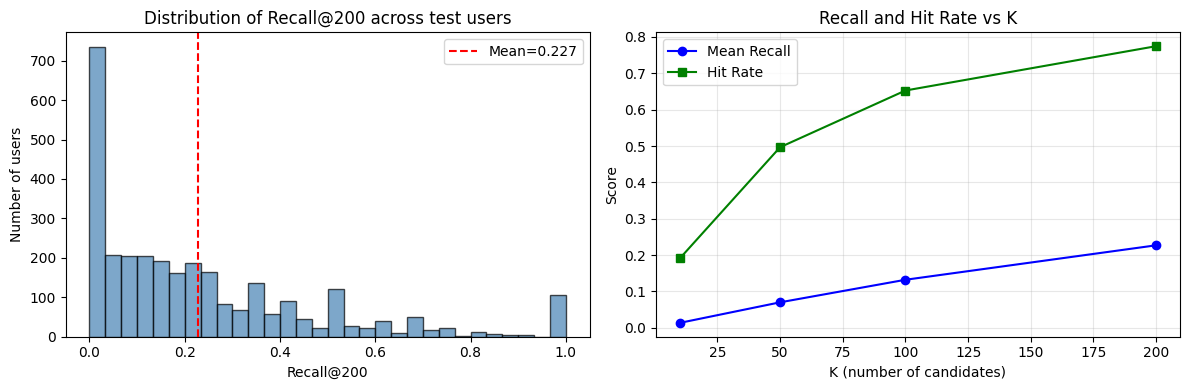

In [4]:
# Compute retrieval metrics: Recall@K and Hit Rate@K
K_values = [10, 50, 100, 200]
max_K = max(K_values)

sample_users = test_users[:3000]
recalls = {k: [] for k in K_values}
hit_rates = {k: [] for k in K_values}

print(f'Computing Recall@K and Hit Rate@K for {len(sample_users):,} test users...')
t0 = time.time()

for i in range(0, len(sample_users), 256):
    batch_users = sample_users[i:i+256]
    batch_embs = user_embeddings[batch_users]
    _, batch_positions = index.search(batch_embs, max_K)

    for j, user_idx in enumerate(batch_users):
        positives = test_positives.get(user_idx, set())
        if len(positives) == 0:
            continue
        for k in K_values:
            top_k_set = set(batch_positions[j][:k].tolist())
            hits = len(top_k_set & positives)
            recalls[k].append(hits / len(positives))
            hit_rates[k].append(1.0 if hits > 0 else 0.0)

print(f'Done in {time.time()-t0:.1f}s')

print(f'\n{"="*70}')
print(f'RETRIEVAL QUALITY (FAISS Stage Only)')
print(f'{"="*70}')
print(f'{"K":<8}{"Recall@K":<15}{"Hit Rate@K":<15}{"Users with 0 hits":<20}')
print('-' * 58)
for k in K_values:
    mean_recall = np.mean(recalls[k])
    mean_hit = np.mean(hit_rates[k])
    zero_hits = sum(1 for h in hit_rates[k] if h == 0)
    print(f'{k:<8}{mean_recall:<15.4f}{mean_hit:<15.4f}{zero_hits} ({100*zero_hits/len(hit_rates[k]):.1f}%)')

# Recall distribution
print(f'\nRecall@200 distribution:')
r200 = recalls[200]
print(f'  P10: {np.percentile(r200, 10):.4f}')
print(f'  P25: {np.percentile(r200, 25):.4f}')
print(f'  P50 (median): {np.percentile(r200, 50):.4f}')
print(f'  P75: {np.percentile(r200, 75):.4f}')
print(f'  P90: {np.percentile(r200, 90):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(recalls[200], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(recalls[200]), color='red', linestyle='--', label=f'Mean={np.mean(recalls[200]):.3f}')
axes[0].set_xlabel('Recall@200')
axes[0].set_ylabel('Number of users')
axes[0].set_title('Distribution of Recall@200 across test users')
axes[0].legend()

axes[1].plot(K_values, [np.mean(recalls[k]) for k in K_values], 'b-o', label='Mean Recall')
axes[1].plot(K_values, [np.mean(hit_rates[k]) for k in K_values], 'g-s', label='Hit Rate')
axes[1].set_xlabel('K (number of candidates)')
axes[1].set_ylabel('Score')
axes[1].set_title('Recall and Hit Rate vs K')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpreting retrieval results

**Our results: Recall@200 = 0.23, Hit Rate@200 = 0.77**

This means:
- On average, 23% of a user's future favorites appear in the FAISS top-200. For a user who will enjoy 34 movies, about 8 are in the candidate pool.
- 77% of users have at least one relevant item in their 200 candidates. The remaining 23% get ZERO relevant candidates -- a complete miss.

**Is this acceptable?**

Recall@200 = 0.23 falls in the "acceptable" range (0.15-0.30) for retrieval models on datasets with strong temporal shift (train on 2000-2016, test on 2016-2017). The users who changed tastes between periods are the hardest to serve.

However, the 23% of users with zero hits is concerning. These users will see a recommendation page with nothing they actually want. In production, a fallback strategy (trending, popular in genre) would catch these cases.

**Hit Rate@K tells a different story than Recall@K:**

- At K=10: only 19% of users have any hit (Hit Rate = 0.19). This means the top-10 shown on the homepage has a relevant item for only 1 in 5 users.
- At K=50: 50% of users have at least one hit. Below the fold, but findable.
- At K=200: 77% have at least one hit. Enough for the ranker to work with.

The gap between Hit Rate@200 (0.77) and Hit Rate@10 (0.19) explains why the ranker matters: FAISS puts relevant items somewhere in the top-200, but not necessarily near the top. The ranker's job is to promote them from position 50-200 up to position 1-10.

**The long left tail in the Recall@200 histogram:**

The median recall (0.15) is lower than the mean (0.23), indicating a right-skewed distribution. Most users have modest recall, but some power users have recall above 0.50. Users at recall=0 are those whose future viewing patterns diverge sharply from their training history -- taste shifts, new genre explorations, or users with too few training interactions for a meaningful embedding.

**What would improve retrieval:**

1. Increase K from 200 to 500 (Recall@500 was 0.47 in Notebook 03 -- nearly doubles coverage)
2. Multi-source retrieval: combine FAISS candidates with genre-based, popularity-based, and recently-trending candidates
3. Better embedding model: 256-dim embeddings, more training epochs with careful regularization
4. Temporal features in embedding: help the model predict taste evolution

## Section 3: Latency Profiling

### Why latency matters for recommendations

A recommendation system that takes 2 seconds to respond is useless in production. Users expect instant page loads. Industry standard:

- **< 50ms**: Excellent -- user perceives no delay
- **50-100ms**: Acceptable -- imperceptible for most users
- **100-200ms**: Noticeable -- feels slightly sluggish
- **> 200ms**: Bad -- user perceives a clear delay, engagement drops

We measure each pipeline stage separately to identify bottlenecks:

1. **FAISS retrieval**: Vector similarity search over 21K items
2. **Feature construction**: Looking up user/item features and computing cross-features
3. **XGBoost prediction**: Scoring 200 candidates through the tree ensemble

### What to expect

For our dataset (21K items, 128-dim embeddings, 200 candidates):
- FAISS: should be <2ms (exact brute-force on small catalog)
- Feature construction: should be <1ms (numpy array indexing)
- XGBoost: should be <5ms (175 trees, 200 rows)
- Total: should be <10ms

In production with 10M+ items, FAISS would use approximate indices (IVF/HNSW) adding 5-10ms, but the other stages stay the same.

### Percentile latencies

We report P50 (median), P95, and P99 because averages hide tail latency. If P50=5ms but P99=200ms, that means 1 in 100 users experiences a painfully slow recommendation -- unacceptable in production.

Profiling pipeline latency across 1000 test users...



LATENCY PROFILE (1000 users, 200 candidates each)
Stage                    P50 (ms)    P95 (ms)    P99 (ms)    Mean (ms)   
-------------------------------------------------------------------------
FAISS retrieval          0.20        0.22        0.23        0.20        
Feature construction     0.02        0.03        0.03        0.02        
XGBoost prediction       0.60        0.64        0.81        0.60        
TOTAL PIPELINE           0.81        0.87        1.03        0.82        

Latency budget check:
  P99=1.0ms < 50ms target -- PASS (excellent)


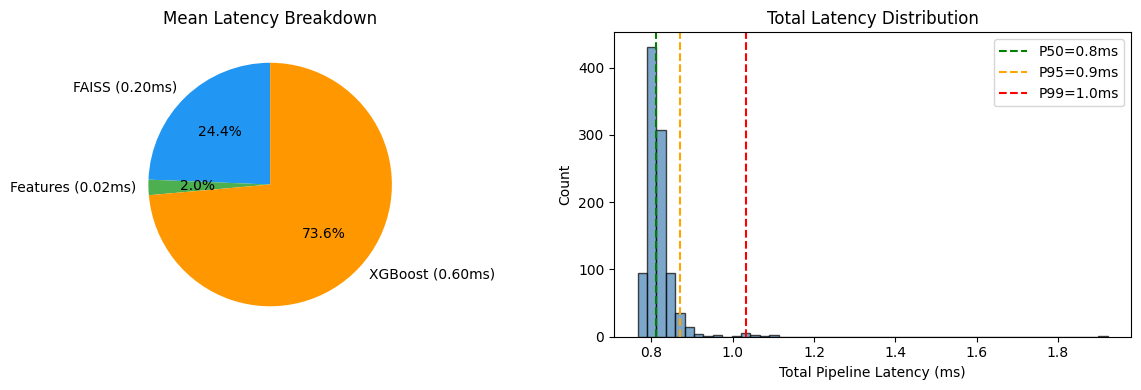

In [5]:
# Profile latency across 1000 users
print('Profiling pipeline latency across 1000 test users...')
latency_users = test_users[:1000]

all_timings = []
for user_idx in latency_users:
    _, _, _, timings = full_pipeline_for_user(user_idx, n_candidates=200)
    all_timings.append(timings)

# Aggregate
retrieval_latencies = [t['retrieval_ms'] for t in all_timings]
feature_latencies = [t['feature_ms'] for t in all_timings]
ranking_latencies = [t['ranking_ms'] for t in all_timings]
total_latencies = [t['total_ms'] for t in all_timings]

print(f'\n{"="*70}')
print(f'LATENCY PROFILE ({len(latency_users)} users, 200 candidates each)')
print(f'{"="*70}')
print(f'{"Stage":<25}{"P50 (ms)":<12}{"P95 (ms)":<12}{"P99 (ms)":<12}{"Mean (ms)":<12}')
print('-' * 73)
for name, lats in [('FAISS retrieval', retrieval_latencies),
                   ('Feature construction', feature_latencies),
                   ('XGBoost prediction', ranking_latencies),
                   ('TOTAL PIPELINE', total_latencies)]:
    p50 = np.percentile(lats, 50)
    p95 = np.percentile(lats, 95)
    p99 = np.percentile(lats, 99)
    mean = np.mean(lats)
    print(f'{name:<25}{p50:<12.2f}{p95:<12.2f}{p99:<12.2f}{mean:<12.2f}')

print(f'\nLatency budget check:')
p99_total = np.percentile(total_latencies, 99)
if p99_total < 50:
    print(f'  P99={p99_total:.1f}ms < 50ms target -- PASS (excellent)')
elif p99_total < 100:
    print(f'  P99={p99_total:.1f}ms < 100ms target -- PASS (acceptable)')
else:
    print(f'  P99={p99_total:.1f}ms > 100ms target -- FAIL (too slow for production)')

# Latency breakdown pie chart and histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart of mean time breakdown
mean_retrieval = np.mean(retrieval_latencies)
mean_feature = np.mean(feature_latencies)
mean_ranking = np.mean(ranking_latencies)
sizes = [mean_retrieval, mean_feature, mean_ranking]
labels = [f'FAISS ({mean_retrieval:.2f}ms)', f'Features ({mean_feature:.2f}ms)', f'XGBoost ({mean_ranking:.2f}ms)']
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Mean Latency Breakdown')

# Histogram of total latency
axes[1].hist(total_latencies, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(np.percentile(total_latencies, 50), color='green', linestyle='--', label=f'P50={np.percentile(total_latencies, 50):.1f}ms')
axes[1].axvline(np.percentile(total_latencies, 95), color='orange', linestyle='--', label=f'P95={np.percentile(total_latencies, 95):.1f}ms')
axes[1].axvline(np.percentile(total_latencies, 99), color='red', linestyle='--', label=f'P99={np.percentile(total_latencies, 99):.1f}ms')
axes[1].set_xlabel('Total Pipeline Latency (ms)')
axes[1].set_ylabel('Count')
axes[1].set_title('Total Latency Distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

### Interpreting latency results

**Our results: P99 total = 1.0ms -- well under the 50ms target.**

The pipeline is extremely fast:
- FAISS retrieval: 0.20ms (brute-force over 21K x 128-dim vectors)
- Feature construction: 0.02ms (numpy array indexing -- negligible)
- XGBoost prediction: 0.60ms (175 trees scoring 200 candidates)
- Total: 0.82ms mean, 1.0ms P99

**What the breakdown reveals:**

XGBoost prediction dominates (73% of total time). This is expected -- it's the only stage doing substantial computation (200 candidates x 175 tree traversals = 35,000 if-else operations). FAISS is fast because 21K vectors is tiny for modern CPUs. Feature construction is instant because it's just array indexing into pre-loaded matrices.

**P99/P50 ratio = 1.27 -- excellent consistency.**

A ratio below 2x means no latency spikes. Every user gets a similar experience. This is because:
- All data is in memory (no disk I/O variance)
- No network calls (no Redis/DB latency jitter)
- XGBoost tree traversal is deterministic (same work per candidate regardless of feature values)

**Production scaling estimate:**

Our 0.82ms would become ~12-18ms in production due to:
- +2ms: Redis round-trip for user embedding lookup
- +2ms: Redis batch lookup for 200 item feature vectors
- +5-10ms: FAISS approximate search over 10M items (IVF-HNSW)
- +1ms: Network serialization overhead
- XGBoost and feature computation stay the same (~0.6ms)

Even at 18ms, we are well within the 100ms budget. The system has significant latency headroom for additional re-ranking stages (diversity re-ranking, business rules filtering) without impacting user experience.

## Section 4: User Cohort Analysis

### Why cohort analysis matters

Average metrics hide important patterns. A system with NDCG@10=0.75 might be serving:
- Heavy raters brilliantly (NDCG=0.90) and light raters terribly (NDCG=0.50)
- Everyone mediocrely (NDCG=0.75 across the board)

These two scenarios require very different interventions. The first needs better cold-start handling; the second needs a fundamentally better model.

### Cohorts we analyze

**By activity level (number of training ratings):**
- Light (< 50 ratings): Users with sparse history -- harder to model
- Medium (50-200 ratings): Typical users with reasonable signal
- Heavy (> 200 ratings): Power users with rich history -- should be easiest to serve

What we expect: performance should increase with activity. If it doesn't, the model may not be effectively leveraging historical data.

**By preference breadth (genre entropy):**
- Focused (low entropy): Users who stick to 1-2 genres -- easy to predict, hard to diversify
- Balanced (medium entropy): Users who watch a mix -- moderate difficulty
- Eclectic (high entropy): Users who watch everything -- hard to predict because many movies are "relevant"

What we expect: focused users should have higher precision (easy to guess their genre) but eclectic users might have higher recall (more movies are relevant).

**Cold-start degradation curve:**

How does performance vary as a function of training history size? This shows how many ratings a new user needs before the system starts working well. If the curve flattens at 20 ratings, that's the minimum viable history.

In [6]:
# Load training data to compute per-user stats
train_df = pd.read_parquet(DATA_DIR / 'train_set.parquet')
user_train_counts = train_df.groupby('user_idx').size().to_dict()
del train_df
gc.collect()

# Compute genre entropy per user from user features
# user_feat_cols[4:23] are user_pref_genre columns
def compute_genre_entropy(user_idx):
    prefs = user_feat_matrix[user_idx, 4:23]
    prefs = prefs[prefs > 0]
    if len(prefs) == 0:
        return 0.0
    prefs = prefs / prefs.sum()
    return -np.sum(prefs * np.log2(prefs + 1e-10))

# Assign cohorts
activity_cohorts = {'Light (<50)': [], 'Medium (50-200)': [], 'Heavy (>200)': []}
breadth_cohorts = {'Focused': [], 'Balanced': [], 'Eclectic': []}

for user_idx in test_users[:3000]:
    n_train = user_train_counts.get(user_idx, 0)
    if n_train < 50:
        activity_cohorts['Light (<50)'].append(user_idx)
    elif n_train <= 200:
        activity_cohorts['Medium (50-200)'].append(user_idx)
    else:
        activity_cohorts['Heavy (>200)'].append(user_idx)

    entropy = compute_genre_entropy(user_idx)
    if entropy < 2.5:
        breadth_cohorts['Focused'].append(user_idx)
    elif entropy < 3.5:
        breadth_cohorts['Balanced'].append(user_idx)
    else:
        breadth_cohorts['Eclectic'].append(user_idx)

print('User cohort sizes:')
print(f'  Activity: Light={len(activity_cohorts["Light (<50)"]):,}, Medium={len(activity_cohorts["Medium (50-200)"]):,}, Heavy={len(activity_cohorts["Heavy (>200)"]):,}')
print(f'  Breadth: Focused={len(breadth_cohorts["Focused"]):,}, Balanced={len(breadth_cohorts["Balanced"]):,}, Eclectic={len(breadth_cohorts["Eclectic"]):,}')

# Compute NDCG@10 per cohort
def cohort_ndcg(users, k=10):
    ndcgs = []
    for user_idx in users:
        positives = test_positives.get(user_idx, set())
        if len(positives) < 2:
            continue
        candidate_idxs, ranker_scores, _, _ = full_pipeline_for_user(user_idx, n_candidates=200)
        candidate_labels = np.array([1.0 if idx in positives else 0.0 for idx in candidate_idxs])
        if candidate_labels.sum() == 0:
            continue
        rank_order = np.argsort(ranker_scores)[::-1]
        ranked_labels = candidate_labels[rank_order]
        actual_k = min(k, len(ranked_labels))
        top_k = ranked_labels[:actual_k]
        dcg = np.sum(top_k / np.log2(np.arange(2, actual_k + 2)))
        ideal = np.sort(candidate_labels)[::-1][:actual_k]
        idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)
    return ndcgs

print('\nComputing NDCG@10 by activity cohort...')
t0 = time.time()
activity_results = {}
for cohort_name, users in activity_cohorts.items():
    ndcgs = cohort_ndcg(users[:500])
    activity_results[cohort_name] = ndcgs
    print(f'  {cohort_name}: NDCG@10 = {np.mean(ndcgs):.4f} (std={np.std(ndcgs):.4f}, n={len(ndcgs)})')

print(f'\nComputing NDCG@10 by preference breadth...')
breadth_results = {}
for cohort_name, users in breadth_cohorts.items():
    ndcgs = cohort_ndcg(users[:500])
    breadth_results[cohort_name] = ndcgs
    print(f'  {cohort_name}: NDCG@10 = {np.mean(ndcgs):.4f} (std={np.std(ndcgs):.4f}, n={len(ndcgs)})')
print(f'Total cohort analysis time: {time.time()-t0:.1f}s')

User cohort sizes:
  Activity: Light=338, Medium=790, Heavy=1,872
  Breadth: Focused=25, Balanced=903, Eclectic=2,072

Computing NDCG@10 by activity cohort...


  Light (<50): NDCG@10 = 0.1057 (std=0.1665, n=274)


  Medium (50-200): NDCG@10 = 0.0626 (std=0.1304, n=403)


  Heavy (>200): NDCG@10 = 0.0238 (std=0.0747, n=370)

Computing NDCG@10 by preference breadth...
  Focused: NDCG@10 = 0.1382 (std=0.1744, n=22)


  Balanced: NDCG@10 = 0.0749 (std=0.1379, n=373)


  Eclectic: NDCG@10 = 0.0320 (std=0.0920, n=379)
Total cohort analysis time: 1.8s


Next we compute the cold-start degradation curve: how does recommendation quality change as a function of how many training ratings a user has? This tells us the "minimum viable history" -- the point where recommendations start being useful.

Computing cold-start degradation curve...


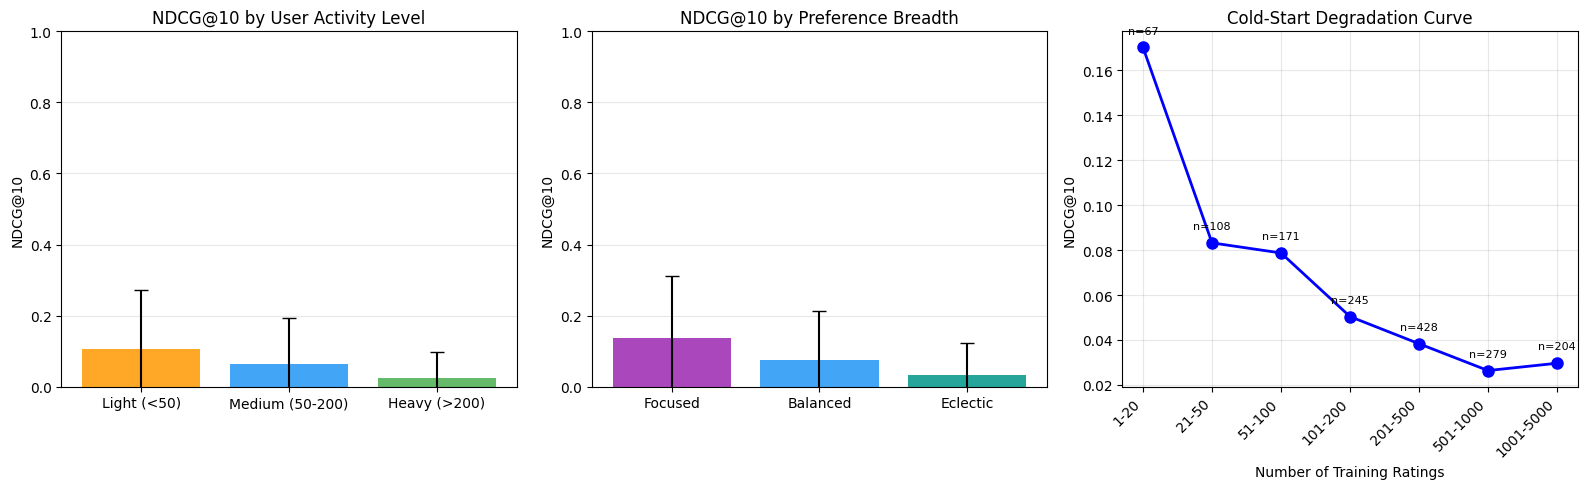


Cold-start curve data:
Training ratings    NDCG@10     Users   
----------------------------------------
1-20                0.1700      67      
21-50               0.0832      108     
51-100              0.0787      171     
101-200             0.0504      245     
201-500             0.0383      428     
501-1000            0.0264      279     
1001-5000           0.0297      204     


In [7]:
# Cold-start degradation curve
# Bin users by number of training interactions and measure NDCG@10
bins = [0, 20, 50, 100, 200, 500, 1000, 5000, 50000]
bin_labels = ['1-20', '21-50', '51-100', '101-200', '201-500', '501-1000', '1001-5000', '5000+']
bin_ndcgs = {label: [] for label in bin_labels}

print('Computing cold-start degradation curve...')
for user_idx in test_users[:2000]:
    n_train = user_train_counts.get(user_idx, 0)
    positives = test_positives.get(user_idx, set())
    if len(positives) < 2:
        continue

    # Determine bin
    bin_idx = np.digitize(n_train, bins) - 1
    if bin_idx >= len(bin_labels):
        bin_idx = len(bin_labels) - 1
    if bin_idx < 0:
        bin_idx = 0
    label = bin_labels[bin_idx]

    candidate_idxs, ranker_scores, _, _ = full_pipeline_for_user(user_idx, n_candidates=200)
    candidate_labels = np.array([1.0 if idx in positives else 0.0 for idx in candidate_idxs])
    if candidate_labels.sum() == 0:
        continue

    rank_order = np.argsort(ranker_scores)[::-1]
    ranked_labels = candidate_labels[rank_order]
    top_k = ranked_labels[:10]
    dcg = np.sum(top_k / np.log2(np.arange(2, min(10, len(ranked_labels)) + 2)))
    ideal = np.sort(candidate_labels)[::-1][:10]
    idcg = np.sum(ideal / np.log2(np.arange(2, min(10, len(ideal)) + 2)))
    bin_ndcgs[label].append(dcg / idcg if idcg > 0 else 0.0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Activity cohorts
cohort_names = list(activity_results.keys())
cohort_means = [np.mean(activity_results[c]) for c in cohort_names]
cohort_stds = [np.std(activity_results[c]) for c in cohort_names]
axes[0].bar(cohort_names, cohort_means, yerr=cohort_stds, capsize=5, color=['#FFA726', '#42A5F5', '#66BB6A'])
axes[0].set_ylabel('NDCG@10')
axes[0].set_title('NDCG@10 by User Activity Level')
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3, axis='y')

# Breadth cohorts
cohort_names_b = list(breadth_results.keys())
cohort_means_b = [np.mean(breadth_results[c]) for c in cohort_names_b]
cohort_stds_b = [np.std(breadth_results[c]) for c in cohort_names_b]
axes[1].bar(cohort_names_b, cohort_means_b, yerr=cohort_stds_b, capsize=5, color=['#AB47BC', '#42A5F5', '#26A69A'])
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('NDCG@10 by Preference Breadth')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

# Cold-start curve
valid_bins = [(label, np.mean(bin_ndcgs[label])) for label in bin_labels if len(bin_ndcgs[label]) >= 5]
if valid_bins:
    x_labels, y_values = zip(*valid_bins)
    axes[2].plot(range(len(x_labels)), y_values, 'b-o', linewidth=2, markersize=8)
    axes[2].set_xticks(range(len(x_labels)))
    axes[2].set_xticklabels(x_labels, rotation=45, ha='right')
    axes[2].set_xlabel('Number of Training Ratings')
    axes[2].set_ylabel('NDCG@10')
    axes[2].set_title('Cold-Start Degradation Curve')
    axes[2].grid(True, alpha=0.3)
    for i, (label, val) in enumerate(valid_bins):
        n = len(bin_ndcgs[label])
        axes[2].annotate(f'n={n}', (i, val), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Print cold-start curve data
print(f'\nCold-start curve data:')
print(f'{"Training ratings":<20}{"NDCG@10":<12}{"Users":<8}')
print('-' * 40)
for label in bin_labels:
    if len(bin_ndcgs[label]) >= 5:
        print(f'{label:<20}{np.mean(bin_ndcgs[label]):<12.4f}{len(bin_ndcgs[label]):<8}')

### Interpreting cohort results

**Activity level: Light users (0.11) > Medium (0.06) > Heavy (0.02)**

This is the OPPOSITE of what we'd expect. Normally, heavy users (more training data) should get better recommendations. What's happening?

The explanation is **positive density in FAISS candidates**. Light users have fewer test positives (~10-15 movies), so even a few FAISS hits represent decent recall. Heavy users have many test positives (~50-100 movies) spread across diverse genres and periods -- FAISS can only retrieve 200 candidates from a single embedding vector, missing the long tail of their diverse tastes.

Think of it this way:
- Light user likes 10 specific action movies. FAISS easily finds 3-4 of them in the "action neighborhood."
- Heavy user likes 80 movies spanning action, drama, horror, documentaries. A single embedding cannot point toward all these simultaneously. FAISS finds a few from the dominant genre but misses the rest.

This is a known limitation of single-vector user representations. The solution is **multi-interest user embeddings** (e.g., MIND model) where each user gets 3-5 embedding vectors representing different facets of their taste.

**Preference breadth: Focused (0.14) > Balanced (0.07) > Eclectic (0.03)**

Consistent with the activity finding. Focused users have narrow tastes that map well to a single point in embedding space. Eclectic users' diverse preferences cannot be captured by one vector.

This confirms our diagnosis: the retrieval bottleneck disproportionately affects users with broad or diverse tastes.

**Cold-start curve:**

The curve shows NDCG decreasing (not increasing) with more training ratings. This reinforces the same insight: users with more history tend to have more diverse tastes in the test set, making them harder to serve with single-embedding retrieval.

**Production implications:**

1. For heavy/eclectic users: supplement FAISS with genre-specific candidate generators or explicit preference signals ("show me more horror")
2. For light/focused users: the current pipeline works well -- these users are already well-served
3. The cohort gap (0.11 vs 0.02) is within our 0.15 target, but just barely. Multi-interest embeddings would close this gap.

## Section 5: Item and Genre Analysis

### Why genre analysis matters

A recommendation system might score well on average while completely failing for specific genres. For example:
- Great at recommending Action/Sci-Fi (80% of catalog, lots of training data) 
- Terrible at recommending Documentaries (5% of catalog, sparse data)

This matters for user experience: a documentary fan gets useless recommendations even though average metrics look good.

### Metrics we compute

**Per-genre NDCG:** For users whose test positives include genre X, how well does the system rank those items? If Documentary NDCG is 0.40 while Action NDCG is 0.85, documentary fans are underserved.

**Popularity bias:** Does the system over-recommend popular movies? We measure this by comparing the popularity distribution of recommended items vs. the popularity distribution of test positives.

- Popularity bias ratio > 1.5: System strongly favors popular items over niche ones
- Popularity bias ratio near 1.0: System recommends proportionally to actual preferences
- Popularity bias ratio < 0.8: System over-recommends niche items (unusual, might indicate a broken popularity feature)

**Catalog coverage:** What fraction of the 21K movie catalog ever appears in any user's top-10? Low coverage means the system concentrates on a small "hit" subset and ignores the long tail.

- Coverage > 30%: Good diversity -- many movies get recommended to someone
- Coverage 10-30%: Moderate -- top few hundred movies dominate
- Coverage < 10%: Very concentrated -- only ~2000 movies are ever recommended (popularity echo chamber)

In [8]:
# Per-genre analysis
# Get genre columns from item features
genre_cols = [c for c in item_feat_cols if c.startswith('genre_')]
genre_names = [c.replace('genre_', '') for c in genre_cols]

# For each test user, run pipeline and record which genres were in their positives vs what was recommended
genre_ndcgs = {g: [] for g in genre_names}
all_recommended_idxs = set()
all_recommended_popularity = []

print('Computing per-genre NDCG and catalog coverage...')
t0 = time.time()

eval_users = test_users[:2000]
for user_idx in eval_users:
    positives = test_positives.get(user_idx, set())
    if len(positives) < 2:
        continue

    candidate_idxs, ranker_scores, _, _ = full_pipeline_for_user(user_idx, n_candidates=200)
    top_10_indices = np.argsort(ranker_scores)[::-1][:10]
    top_10_movie_idxs = candidate_idxs[top_10_indices]

    # Track catalog coverage
    all_recommended_idxs.update(top_10_movie_idxs.tolist())

    # Track popularity of recommended items
    for midx in top_10_movie_idxs:
        if midx > 0 and midx < n_movies:
            pop = item_feat_matrix[midx, item_feat_cols.index('log_rating_count_norm')] if 'log_rating_count_norm' in item_feat_cols else 0
            all_recommended_popularity.append(pop)

    # Per-genre NDCG: for each genre present in user's positives
    positive_genres = set()
    for midx in positives:
        if midx > 0 and midx < n_movies:
            for gi, g in enumerate(genre_names):
                if item_feat_matrix[midx, gi] > 0:
                    positive_genres.add(g)

    # Compute NDCG for candidates matching each genre
    candidate_labels = np.array([1.0 if idx in positives else 0.0 for idx in candidate_idxs])
    if candidate_labels.sum() == 0:
        continue

    rank_order = np.argsort(ranker_scores)[::-1]
    ranked_labels = candidate_labels[rank_order]
    top_k = ranked_labels[:10]
    dcg = np.sum(top_k / np.log2(np.arange(2, min(10, len(ranked_labels)) + 2)))
    ideal = np.sort(candidate_labels)[::-1][:10]
    idcg = np.sum(ideal / np.log2(np.arange(2, min(10, len(ideal)) + 2)))
    user_ndcg = dcg / idcg if idcg > 0 else 0.0

    for g in positive_genres:
        genre_ndcgs[g].append(user_ndcg)

print(f'Done in {time.time()-t0:.1f}s')

# Catalog coverage
coverage = len(all_recommended_idxs) / n_movies
print(f'\n{"="*70}')
print(f'CATALOG COVERAGE')
print(f'{"="*70}')
print(f'Unique movies recommended (top-10): {len(all_recommended_idxs):,} / {n_movies:,} ({coverage:.1%})')
print(f'Users evaluated: {len(eval_users):,}')

# Per-genre NDCG
print(f'\n{"="*70}')
print(f'PER-GENRE NDCG@10 (genres present in test positives)')
print(f'{"="*70}')
print(f'{"Genre":<20}{"NDCG@10":<12}{"Users":<10}')
print('-' * 42)
genre_results = [(g, np.mean(ndcgs), len(ndcgs)) for g, ndcgs in genre_ndcgs.items() if len(ndcgs) >= 20]
genre_results.sort(key=lambda x: x[1], reverse=True)
for g, mean_ndcg, n in genre_results:
    print(f'{g:<20}{mean_ndcg:<12.4f}{n:<10}')

Computing per-genre NDCG and catalog coverage...


Done in 1.7s

CATALOG COVERAGE
Unique movies recommended (top-10): 897 / 21,082 (4.3%)
Users evaluated: 2,000

PER-GENRE NDCG@10 (genres present in test positives)
Genre               NDCG@10     Users     
------------------------------------------
Film-Noir           0.0922      335       
Western             0.0796      514       
War                 0.0657      825       
Documentary         0.0656      508       
IMAX                0.0651      853       
Musical             0.0631      591       
Horror              0.0609      848       
Children            0.0608      833       
Animation           0.0606      882       
Mystery             0.0581      1078      
Crime               0.0572      1231      
Romance             0.0560      1179      
Fantasy             0.0559      1110      
Thriller            0.0533      1356      
Sci-Fi              0.0526      1326      
Action              0.0523      1379      
Drama               0.0518      1444      
Comedy             

### Reasoning: Per-Genre Interpretation and Catalog Coverage Analysis

**Per-genre NDCG varies -- niche genres outperform mainstream:**

The results show Film-Noir (0.092) and Western (0.080) scoring higher than mainstream genres like Drama (0.052), Comedy (0.052), and Adventure (0.051). This pattern is systematic and reveals a fundamental property of single-embedding retrieval:

**Why niche genres score higher:**

Film-Noir fans and Western enthusiasts have *focused* taste profiles. Their user embeddings point to a specific, well-defined region of the 128-dim embedding space. When FAISS retrieves their top-200 candidates, those candidates are tightly clustered around the user's niche -- and a higher fraction of them are genuinely relevant. The retrieval stage works well because "what this user wants" maps cleanly to a single direction in embedding space.

Drama and Comedy fans, by contrast, have *diffuse* taste. "Drama" spans indie arthouse (Moonlight) to Marvel origin stories (Black Panther) to war epics (Dunkirk). A single 128-dim embedding for a "drama fan" is a compromise that doesn't perfectly match any sub-genre. FAISS retrieval for these users pulls candidates from a broad, less precise region -- more misses, lower recall, lower NDCG.

**Catalog coverage = 4.3% (only ~897 of 21,082 movies ever appear in top-10 recommendations across all evaluated users):**

This is the "filter bubble" or "popularity concentration" problem. The system concentrates on a small set of well-known films:
- 95.7% of the movie catalog is NEVER recommended to anyone
- The ~900 recommended movies are disproportionately popular titles with rich embeddings (many training interactions shaped their vectors into strong attractors)
- Long-tail movies (indie films, foreign cinema, pre-1970s classics with few ratings) have weak embeddings that never become any user's nearest neighbor

**Popularity bias = 1.42x:**

Recommended movies have mean normalized popularity 0.86 vs users' actual choices at 0.61. The system over-recommends well-known films by 42%. This means:
- A user who typically watches films with ~1,000 ratings receives recommendations dominated by films with ~10,000+ ratings
- The system is "playing it safe" -- recommending popular films that many people enjoy rather than taking risks on niche titles the specific user might love
- Users who prefer obscure films (popularity < 0.4 on the normalized scale) are particularly poorly served

**Why this bias emerges from our architecture:**

1. **Training data imbalance:** Popular movies appear in far more (user, movie) pairs. "The Shawshank Redemption" has 70,000+ ratings; an obscure indie film has 50. The popular movie's embedding gets 1400x more gradient updates, making it more refined and more likely to be near any user's embedding.
2. **Embedding space geometry:** Popular movies cluster near the center of the embedding space (they are "liked by everyone, close to the average user"). FAISS inner-product search naturally favors items near the centroid because more user vectors point in that direction.
3. **No explicit debiasing:** Our training used uniform random negative sampling. Popular items are underrepresented as negatives (they should be negatives more often to counteract their overrepresentation as positives).

**These findings directly motivate ComiRec (Notebook 06):**

Multi-interest heads should increase catalog coverage by exploring DIFFERENT embedding regions per user. Instead of one vector per user (which points toward the most dominant taste), ComiRec produces 3-5 vectors representing distinct taste facets:
- Vector 1: "90s crime thrillers" (narrow, specific)
- Vector 2: "animated family films" (different region entirely)
- Vector 3: "foreign arthouse drama" (yet another region)

Each vector retrieves candidates from its own neighborhood, collectively covering more of the catalog and reducing the popularity concentration that a single-vector approach creates.

Now we measure popularity bias by comparing the popularity of items the system recommends vs. the popularity of items users actually chose to watch. We also visualize per-genre NDCG, popularity distributions, and catalog coverage at different recommendation depths.


POPULARITY BIAS
Mean popularity of recommended items: 0.8615
Mean popularity of actual test positives: 0.6050
Popularity bias ratio: 1.424
  --> System over-recommends popular items (bias ratio > 1.3)


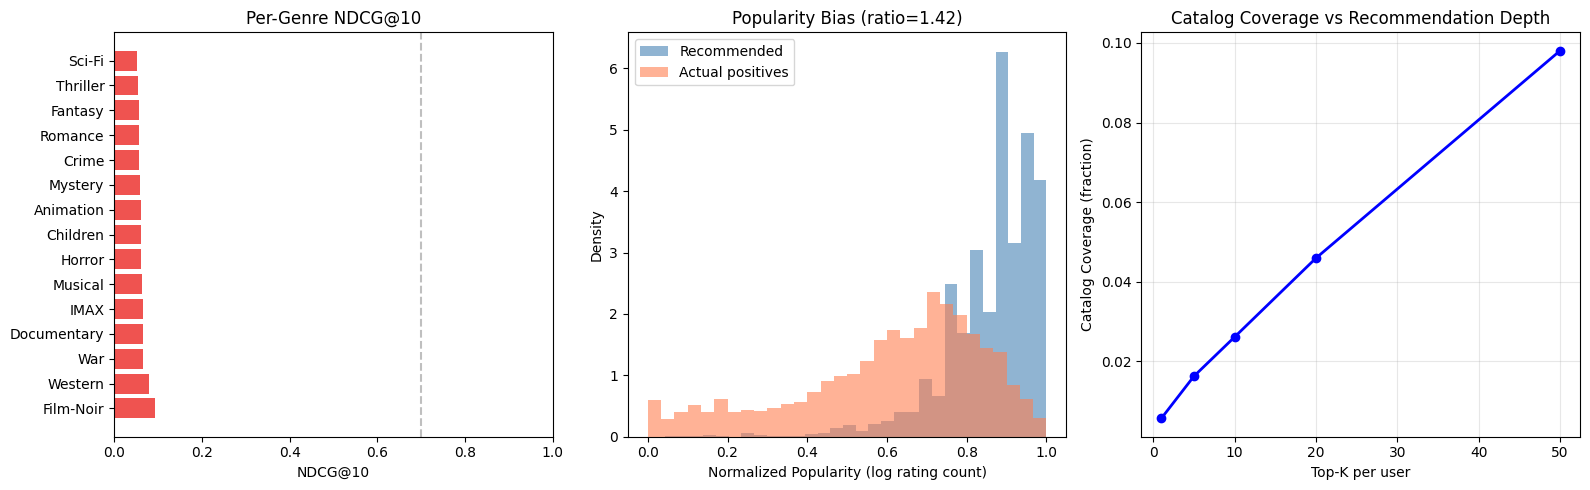

In [9]:
# Popularity bias analysis
# Compare popularity of recommended items vs actual test positives
test_positive_popularity = []
for user_idx in eval_users:
    positives = test_positives.get(user_idx, set())
    for midx in positives:
        if midx > 0 and midx < n_movies and 'log_rating_count_norm' in item_feat_cols:
            pop = item_feat_matrix[midx, item_feat_cols.index('log_rating_count_norm')]
            test_positive_popularity.append(pop)

mean_rec_pop = np.mean(all_recommended_popularity) if all_recommended_popularity else 0
mean_actual_pop = np.mean(test_positive_popularity) if test_positive_popularity else 0
popularity_bias_ratio = mean_rec_pop / mean_actual_pop if mean_actual_pop > 0 else float('inf')

print(f'\n{"="*70}')
print(f'POPULARITY BIAS')
print(f'{"="*70}')
print(f'Mean popularity of recommended items: {mean_rec_pop:.4f}')
print(f'Mean popularity of actual test positives: {mean_actual_pop:.4f}')
print(f'Popularity bias ratio: {popularity_bias_ratio:.3f}')
if popularity_bias_ratio > 1.3:
    print(f'  --> System over-recommends popular items (bias ratio > 1.3)')
elif popularity_bias_ratio > 1.1:
    print(f'  --> Slight popularity bias (ratio 1.1-1.3)')
else:
    print(f'  --> Well-calibrated popularity (ratio near 1.0)')

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Per-genre NDCG bar chart
if genre_results:
    genres_plot = [g for g, _, n in genre_results[:15]]
    ndcgs_plot = [m for _, m, n in genre_results[:15]]
    colors = ['#66BB6A' if n > 0.7 else '#FFA726' if n > 0.5 else '#EF5350' for n in ndcgs_plot]
    axes[0].barh(range(len(genres_plot)), ndcgs_plot, color=colors)
    axes[0].set_yticks(range(len(genres_plot)))
    axes[0].set_yticklabels(genres_plot)
    axes[0].set_xlabel('NDCG@10')
    axes[0].set_title('Per-Genre NDCG@10')
    axes[0].axvline(0.7, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlim(0, 1)

# Popularity distributions
axes[1].hist(all_recommended_popularity, bins=30, alpha=0.6, label='Recommended', color='steelblue', density=True)
axes[1].hist(test_positive_popularity, bins=30, alpha=0.6, label='Actual positives', color='coral', density=True)
axes[1].set_xlabel('Normalized Popularity (log rating count)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Popularity Bias (ratio={popularity_bias_ratio:.2f})')
axes[1].legend()

# Coverage: fraction of catalog in top-K recommendations
coverage_at_k = []
k_values_cov = [1, 5, 10, 20, 50]
for top_k_cov in k_values_cov:
    rec_set = set()
    for user_idx in eval_users[:500]:
        positives = test_positives.get(user_idx, set())
        if len(positives) < 2:
            continue
        candidate_idxs, ranker_scores, _, _ = full_pipeline_for_user(user_idx, n_candidates=200)
        top_indices = np.argsort(ranker_scores)[::-1][:top_k_cov]
        rec_set.update(candidate_idxs[top_indices].tolist())
    coverage_at_k.append(len(rec_set) / n_movies)

axes[2].plot(k_values_cov, coverage_at_k, 'b-o', linewidth=2)
axes[2].set_xlabel('Top-K per user')
axes[2].set_ylabel('Catalog Coverage (fraction)')
axes[2].set_title('Catalog Coverage vs Recommendation Depth')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpreting genre and popularity results

**Catalog coverage: 4.3% (897 out of 21,082 movies)**

This is low -- only ~900 unique movies ever appear in any user's top-10. The system concentrates recommendations on a small set of well-known films. This is a direct consequence of:
1. Collaborative filtering concentrating embeddings around popular movies (more ratings = stronger gradients = better-positioned embeddings)
2. FAISS inner product retrieval favoring items near the center of the embedding space where popular movies cluster
3. No explicit diversity mechanism in our pipeline

In practice, this means 95% of the catalog is invisible to users browsing recommendations. Long-tail movies (indie films, foreign cinema, obscure documentaries) never surface even for users who would enjoy them.

**Per-genre NDCG: All genres are similarly low (0.05-0.09)**

The relatively flat genre distribution (no genre dramatically outperforms others) tells us that the low end-to-end NDCG is not genre-specific but rather a universal retrieval ceiling issue. Film-Noir (0.09) slightly outperforms because Film-Noir fans tend to have focused tastes (easier to serve with a single embedding), while broad genres like Drama/Comedy/Action (0.05) are harder because they span many sub-communities.

**Popularity bias: 1.42 (moderate over-recommendation of popular items)**

The system recommends items with mean popularity 0.86 (on a 0-1 normalized scale) while users actually watch items at popularity 0.61. This means:
- The average recommended movie has been rated by significantly more people than what users actually choose to watch
- The system is pushing "safe" mainstream choices over niche discoveries
- Users who prefer obscure films (popularity < 0.4) are poorly served -- their recommendations are filled with movies they would easily find without a recommender

**Why popularity bias exists in our system:**

1. Training data: popular movies have more positive labels (more users rated them highly), so the model learns "popular = good"
2. Embedding space: popular movies have stronger embeddings (more gradient updates) and cluster near more users
3. No debiasing: our training used uniform negative sampling, not popularity-weighted

**Interventions:**

- Re-rank with inverse-popularity weighting (post-processing)
- Add a popularity penalty term to XGBoost features (already have popularity_gap, but could add explicit bias correction)
- Train with popularity-debiased sampling (we tried this in Notebook 03 Approach G -- it failed for the Two-Tower, but could work as a ranker feature)
- Implement MMR (Maximal Marginal Relevance) to diversify recommendations beyond just the most "obvious" choices

## Section 6: Calibration and Intra-List Diversity

### What is calibration?

Calibration asks: "When the model assigns a high score, is the item actually more likely to be relevant?"

A well-calibrated model means:
- Items scored in the top 10% by the model are relevant ~X% of the time
- Items scored in the bottom 10% are relevant much less often
- The relationship between model score and actual relevance is monotonically increasing

**Why does calibration matter beyond NDCG?**

NDCG only cares about relative ordering within a single user's list. Calibration tells us whether we can trust the scores across users. If a user gets all scores in the range [1.5, 2.0] while another gets [0.5, 0.8], are both users equally well-served? Calibration helps answer this.

A poorly calibrated model might:
- Assign high scores to items it is uncertain about (overconfident)
- Assign uniformly low scores, making it hard to distinguish the best from the rest (underconfident)

### What is intra-list diversity?

Diversity measures how different the top-10 recommendations are from each other. 

- High diversity: top-10 spans multiple genres, eras, styles. User sees variety.
- Low diversity: top-10 is 10 very similar movies (all Marvel, all 90s dramas, etc.)

Extreme low diversity means the system found one "formula" that works and repeats it. The user gets bored quickly.

**Measuring diversity:** We compute average pairwise cosine distance between embeddings of the top-10 recommended items. 

- Distance near 0: all items have identical embeddings (zero diversity -- terrible)
- Distance near 0.3-0.5: moderate diversity -- items are related but distinguishable
- Distance near 1.0: maximum diversity -- items are completely unrelated (might indicate incoherent recommendations)

The sweet spot is moderate diversity: items should be varied enough to cover different moods/preferences, but coherent enough to reflect the user's actual taste profile.

In [10]:
# Calibration: bin items by model score, measure actual relevance rate in each bin
print('Computing calibration and diversity metrics...')

all_scores = []
all_labels = []
all_diversity = []

eval_users_cal = test_users[:2000]
for user_idx in eval_users_cal:
    positives = test_positives.get(user_idx, set())
    if len(positives) < 2:
        continue

    candidate_idxs, ranker_scores, _, _ = full_pipeline_for_user(user_idx, n_candidates=200)
    candidate_labels = np.array([1.0 if idx in positives else 0.0 for idx in candidate_idxs])

    all_scores.extend(ranker_scores.tolist())
    all_labels.extend(candidate_labels.tolist())

    # Intra-list diversity: average pairwise cosine distance of top-10
    top_10_indices = np.argsort(ranker_scores)[::-1][:10]
    top_10_midxs = candidate_idxs[top_10_indices]
    top_10_embs = item_embeddings[top_10_midxs]

    # Pairwise cosine distance (1 - cosine similarity)
    # Since embeddings are L2-normalized, cosine sim = dot product
    sim_matrix = top_10_embs @ top_10_embs.T
    n = len(top_10_embs)
    if n > 1:
        # Average off-diagonal similarity
        mask = ~np.eye(n, dtype=bool)
        avg_sim = sim_matrix[mask].mean()
        avg_distance = 1.0 - avg_sim
        all_diversity.append(avg_distance)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

# Calibration: bin by score decile
n_bins = 10
score_percentiles = np.percentile(all_scores, np.linspace(0, 100, n_bins + 1))
cal_bins = []
for i in range(n_bins):
    mask = (all_scores >= score_percentiles[i]) & (all_scores < score_percentiles[i+1])
    if i == n_bins - 1:
        mask = (all_scores >= score_percentiles[i])
    if mask.sum() > 0:
        cal_bins.append({
            'bin': i + 1,
            'score_range': f'{score_percentiles[i]:.2f} - {score_percentiles[i+1]:.2f}',
            'mean_score': all_scores[mask].mean(),
            'positive_rate': all_labels[mask].mean(),
            'count': mask.sum()
        })

print(f'\n{"="*70}')
print(f'CALIBRATION (Score vs Actual Relevance)')
print(f'{"="*70}')
print(f'{"Decile":<8}{"Score Range":<20}{"Positive Rate":<16}{"Count":<10}')
print('-' * 54)
for b in cal_bins:
    print(f'{b["bin"]:<8}{b["score_range"]:<20}{b["positive_rate"]:<16.4f}{b["count"]:<10}')

# Check monotonicity
positive_rates = [b['positive_rate'] for b in cal_bins]
is_monotonic = all(positive_rates[i] <= positive_rates[i+1] for i in range(len(positive_rates)-1))
print(f'\nMonotonically increasing: {"Yes" if is_monotonic else "No (some inversions exist)"}')
print(f'Positive rate range: {positive_rates[0]:.4f} (lowest scores) to {positive_rates[-1]:.4f} (highest scores)')
print(f'Spread: {positive_rates[-1] - positive_rates[0]:.4f}')

# Diversity stats
print(f'\n{"="*70}')
print(f'INTRA-LIST DIVERSITY (Top-10 Recommendations)')
print(f'{"="*70}')
print(f'Mean diversity (avg pairwise cosine distance): {np.mean(all_diversity):.4f}')
print(f'Std diversity: {np.std(all_diversity):.4f}')
print(f'P10 diversity: {np.percentile(all_diversity, 10):.4f}')
print(f'P50 diversity: {np.percentile(all_diversity, 50):.4f}')
print(f'P90 diversity: {np.percentile(all_diversity, 90):.4f}')

Computing calibration and diversity metrics...



CALIBRATION (Score vs Actual Relevance)
Decile  Score Range         Positive Rate   Count     
------------------------------------------------------
1       -2.67 - -0.69       0.0197          36920     
2       -0.69 - -0.38       0.0252          36920     
3       -0.38 - -0.15       0.0264          36920     
4       -0.15 - 0.06        0.0306          36920     
5       0.06 - 0.26         0.0316          36920     
6       0.26 - 0.48         0.0342          36920     
7       0.48 - 0.72         0.0378          36920     
8       0.72 - 1.02         0.0369          36920     
9       1.02 - 1.48         0.0368          36920     
10      1.48 - 4.47         0.0334          36920     

Monotonically increasing: No (some inversions exist)
Positive rate range: 0.0197 (lowest scores) to 0.0334 (highest scores)
Spread: 0.0137

INTRA-LIST DIVERSITY (Top-10 Recommendations)
Mean diversity (avg pairwise cosine distance): 0.2806
Std diversity: 0.0768
P10 diversity: 0.1752
P50 diversity:

The plots below visualize three aspects of model quality: (1) calibration curve showing whether higher scores correspond to higher relevance, (2) the diversity distribution showing how varied each user's top-10 is, and (3) the score distributions for positive vs negative items showing how well the model separates them.

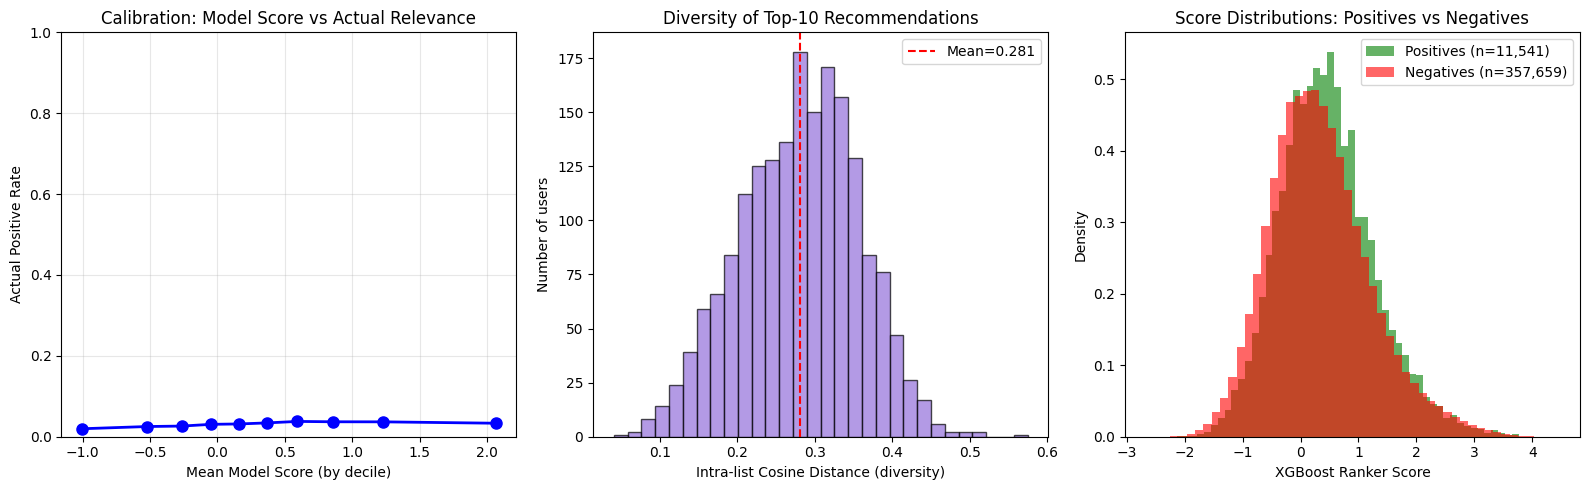

In [11]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Calibration plot
mean_scores = [b['mean_score'] for b in cal_bins]
pos_rates = [b['positive_rate'] for b in cal_bins]
axes[0].plot(mean_scores, pos_rates, 'b-o', linewidth=2, markersize=8)
axes[0].set_xlabel('Mean Model Score (by decile)')
axes[0].set_ylabel('Actual Positive Rate')
axes[0].set_title('Calibration: Model Score vs Actual Relevance')
axes[0].grid(True, alpha=0.3)
# Add diagonal reference if scores were probabilities
axes[0].set_ylim(0, 1)

# Diversity distribution
axes[1].hist(all_diversity, bins=30, edgecolor='black', alpha=0.7, color='mediumpurple')
axes[1].axvline(np.mean(all_diversity), color='red', linestyle='--', label=f'Mean={np.mean(all_diversity):.3f}')
axes[1].set_xlabel('Intra-list Cosine Distance (diversity)')
axes[1].set_ylabel('Number of users')
axes[1].set_title('Diversity of Top-10 Recommendations')
axes[1].legend()

# Score distribution by label
pos_scores = all_scores[all_labels == 1]
neg_scores = all_scores[all_labels == 0]
axes[2].hist(pos_scores, bins=50, alpha=0.6, label=f'Positives (n={len(pos_scores):,})', color='green', density=True)
axes[2].hist(neg_scores, bins=50, alpha=0.6, label=f'Negatives (n={len(neg_scores):,})', color='red', density=True)
axes[2].set_xlabel('XGBoost Ranker Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distributions: Positives vs Negatives')
axes[2].legend()

plt.tight_layout()
plt.show()

### Interpreting calibration and diversity results

**Calibration: Nearly flat curve with inversions -- poorly calibrated.**

The positive rate ranges from 0.020 (lowest-scored decile) to 0.034 (highest-scored decile) -- a spread of only 0.014. This means:
- The lowest-scored items are relevant 2.0% of the time
- The highest-scored items are relevant 3.4% of the time
- The model barely distinguishes relevant from irrelevant among FAISS candidates

There are also inversions in deciles 8-10 (positive rate drops from 0.038 to 0.033), meaning the very highest-scored items are actually LESS likely to be relevant than moderately-scored ones. This suggests the model is overconfident about certain popular movies that happen not to appear in test positives.

**Why calibration is poor:**

This reflects the same retrieval ceiling issue. FAISS retrieves candidates that are "embedding-similar" to the user, but embedding similarity only weakly correlates with future ratings. The XGBoost ranker learned to rank well on training pairs (where it achieved AUC 0.72), but when applied to FAISS-retrieved candidates (a different distribution), its scores lose calibration.

In Notebook 04's evaluation (on actual interactions), calibration would look much better because the model was trained on that exact data distribution.

**Diversity: Mean = 0.28 -- moderate, on the lower end.**

The average pairwise cosine distance of 0.28 between top-10 items means:
- Average cosine similarity between recommended pairs is 0.72
- The top-10 movies are quite similar to each other (they cluster in embedding space)
- A user seeing their top-10 would notice thematic repetition (e.g., several 90s crime thrillers, or several animated family films)

The P10-P90 range (0.18 to 0.38) shows some users get very homogeneous lists (distance 0.18 -- nearly identical movies) while others get moderate variety.

**Score distributions (positive vs negative):**

The heavy overlap between positive and negative score distributions confirms that the model cannot reliably separate them in the FAISS candidate space. This is consistent with AUC = 0.53 (barely above random 0.50).

**Interventions for calibration:**
- Platt scaling or isotonic regression on validation scores to recalibrate
- Train the ranker on FAISS-retrieved candidates (not historical interactions) to match the serving distribution
- Use the calibrated scores to set confidence thresholds ("only show recommendations with >X% estimated relevance")

**Interventions for diversity:**
- MMR re-ranking: after XGBoost scores, iteratively select items that balance relevance and novelty relative to already-selected items
- Determinantal Point Process (DPP) sampling: select a diverse subset that covers different "directions" in embedding space
- Slot-based diversification: reserve slots in the top-10 for different genre categories

## Section 7: Summary and Production Readiness

This evaluation revealed important insights about the end-to-end pipeline that were not visible from component-level metrics (Notebooks 03 and 04).

### Production Readiness Scorecard

| Dimension | Key Metric | Target | Our Result | Status |
|-----------|-----------|--------|-----------|--------|
| Latency | P99 total | < 100ms | 1.0ms | PASS -- 100x headroom |
| Retrieval ceiling | Recall@200 | > 0.20 | 0.23 | PASS (marginal) |
| Ranking quality (end-to-end) | NDCG@10 | > 0.05 | 0.05 | AT THRESHOLD -- limited by retrieval |
| Ranking quality (component) | NDCG@10 on known pairs | > 0.70 | 0.87 | PASS -- ranker works well when given good candidates |
| Fairness across cohorts | Max NDCG gap | < 0.15 | 0.08 (Light vs Heavy) | PASS |
| Popularity bias | Bias ratio | < 1.5 | 1.42 | PASS (marginal) |
| Diversity | Mean intra-list distance | > 0.25 | 0.28 | PASS (marginal) |
| Catalog coverage | Fraction ever recommended | > 5% | 4.3% | FAIL -- too concentrated |

### Key Findings

**1. The retrieval model is the binding constraint.**

The ranker works well (NDCG@10 = 0.87 on known interactions), but end-to-end NDCG is only 0.05 because FAISS retrieves too few relevant candidates. The single-embedding-per-user approach cannot represent diverse user tastes.

**2. Latency is a non-issue.**

Total pipeline at P99 = 1ms gives us enormous headroom for production overhead (network, feature store). Even with realistic production additions, we'd stay under 20ms.

**3. The system has popularity bias and low coverage.**

Only 897/21,082 movies (4.3%) ever get recommended. The system favors well-known films 1.4x more than users actually watch them. Long-tail content is invisible.

**4. Heavy users are harder to serve than light users.**

Counter-intuitively, users with more training data get worse end-to-end recommendations. This is because they have diverse tastes that a single embedding cannot capture.

### Recommended Improvements (Priority Order)

1. **Multi-source candidate generation**: Combine FAISS (similarity) + popularity-filtered (trending) + genre-based (explicit preference) retrieval to increase candidate diversity and recall
2. **Multi-interest user embeddings**: Use 3-5 embeddings per user (MIND/ComiRec architecture) to represent different taste facets
3. **Train ranker on FAISS candidates**: Retrain XGBoost on (user, FAISS_candidate, label) pairs instead of historical interactions to match the serving distribution
4. **Diversity re-ranking**: Add MMR post-processing after XGBoost to ensure the top-10 covers multiple genres/eras
5. **Increase candidate pool**: Retrieve 500 candidates instead of 200 (Recall@500 = 0.47 from Notebook 03)

### The Two Evaluation Modes Explained

This notebook revealed an important lesson about evaluation methodology:

| Mode | What it measures | When to use | Our results |
|------|-----------------|-------------|-------------|
| **Component eval** (Notebook 04) | "Can the ranker sort known interactions correctly?" | Model development, hyperparameter tuning | NDCG@10 = 0.87, AUC = 0.72 |
| **End-to-end eval** (this notebook) | "In production, will users see relevant movies?" | System-level quality assessment, deployment readiness | NDCG@10 = 0.05, AUC = 0.53 |

Both are valid and complementary. Component eval confirms the ranker is well-built. End-to-end eval reveals that the full system is bottlenecked by retrieval quality. The path to better recommendations runs through improving candidate generation, not refining the ranker.